<a href="https://colab.research.google.com/github/lakshmisnairofficial-afk/ML-LAB/blob/main/MULTIPLE_LINEAR_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data = {
    'Area' : [1200,1500,1800,-2400,300,
              3500,4000,4500,5000,5500],
    'Bedrooms' : [2,3,3,4,5,
                  5,6,6,7,7],
    'Age' : [10,5,8,2,1,
             3,2,4,1,2],
    'Distance' : [5,3,4,2,1,
                  2,1,3,2,1],
    'Price' : [250,320,340,450,600,
               650,700,720,800,850]

}
df = pd.DataFrame(data)

# Remove rows where 'Area' is negative
df = df[df['Area'] >= 0]

print(df)

   Area  Bedrooms  Age  Distance  Price
0  1200         2   10         5    250
1  1500         3    5         3    320
2  1800         3    8         4    340
4   300         5    1         1    600
5  3500         5    3         2    650
6  4000         6    2         1    700
7  4500         6    4         3    720
8  5000         7    1         2    800
9  5500         7    2         1    850


In [ ]:
X = df[['Area', 'Bedrooms', 'Age','Distance']]
y = df['Price']
model = LinearRegression()
model.fit(X,y)
y_pred = model.predict(X)

In [ ]:
print("\nModel parameters\n")

print("Intercept:")
print(model.intercept_)

print("\ncoefficients:")
for feature,coef in zip(X.columns,model.coef_):
  print(feature, ":" ,coef)


Model parameters

Intercept:
-26.70640886476349

coefficients:
Area : -0.0008171713605212228
Bedrooms : 125.30988517283505
Age : 10.524492122343645
Distance : -18.17500936745511


In [ ]:
print("\nREGRESSION EQUATION\n")

print("Price = ")
for feature, coef in zip(X.columns, model.coef_):
  print(f"({coef:.4f} * {feature}) + ")
print(model.intercept_)


REGRESSION EQUATION

Price = 
(-0.0008 * Area) + 
(125.3099 * Bedrooms) + 
(10.5245 * Age) + 
(-18.1750 * Distance) + 
-26.70640886476349


In [ ]:
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("\nEVALUATION METRICS\n")
print("Mean sqared error (MSE):",mse)
print("R-sqaured error (R2):",(r2,4))


EVALUATION METRICS

Mean sqared error (MSE): 641.5792650325668
R-sqaured error (R2): (0.9853702155093638, 4)


In [ ]:
new_house=pd.DataFrame({
    'Area':[2800],
    'Bedrooms':[4],
    'Age':[2],
    'Distance':[2]
})

predicted_price = model.predict(new_house)
print("\nNEW HOUSE PREDICTION\n")
print("Predicted Price:",predicted_price[0],2)


NEW HOUSE PREDICTION

Predicted Price: 456.9440175268944 2


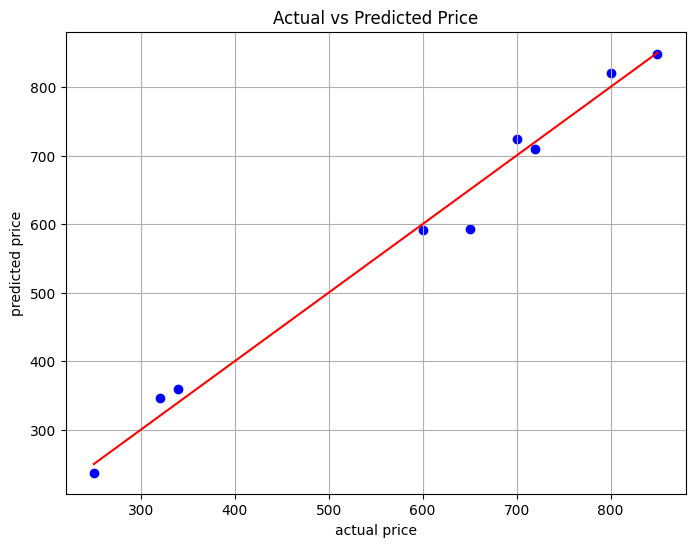

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue')
plt.plot([y.min(),y.max()],[y.min(),y.max()],color='red')
plt.xlabel('actual price')
plt.ylabel('predicted price')
plt.title('Actual vs Predicted Price')
plt.grid(True)
plt.show()